#### translating zoef from .ncl to python

two ncl scripts: 
1. Z.month.EOF.ncl - compute z EOF using monthly data 
2. daily.pc1.nc - project monthly eof to daily z anom data to pc

Problem: projected daily pc1 do not match that computed from ncl

Potential problem:
- data resolution (I used 6 hourly data to average to monthly)
- scaling problems (e.g. cosine weighting, standardization of projected pc1), especially when internal functions of ncl and python are used

Written by: Rachel Wu, 15.12.2025

In [7]:
import numpy as np
import xarray as xr

import os
import glob

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

1. compute monthly zeof
- we only have 6 hourly data in our working directory, so I am averaging them to get monthly data for a given month
- in this script, I am computing for Jun, mon = 6

In [9]:
mon = 6
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [10]:
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

In [11]:
# pick the month then average within each year -> (year, lat, lon)
z_mon = (
    gh_6h_mon['var129']
    .where(gh_6h_mon['time'].dt.month == mon, drop=True)
    .groupby('time.year').mean('time')
)

# convert to get z
pwt_mon = (z_mon / 9.8)

# weights, cosine lat; ncl: wgt = sqrt(cos(OBmslp_1d&lat*0.01745329))
w  = np.sqrt(np.cos(np.deg2rad(pwt_mon['lat'])))

# cosine weight anomalies
da_wgt = pwt_mon*w

# compute climatology for the weighted field
clim = da_wgt.mean('year')
pwt_anom = da_wgt - clim

da = pwt_anom.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()

- eof analysis
- EOF function I copied from aostools, from Martin

In [12]:
def eof(X,n=-1,detrend='constant',eof_in=None):
	"""Principal Component Analysis / Empirical Orthogonal Functions / SVD

		Uses Singular Value Decomposition to find the dominant modes of variability.
		The field X can be reconstructed with Y = dot(EOF,PC) + X.mean(axis=time)

		INPUTS:
			X	-- Field, shape (time x space).
			n	-- Number of modes to extract. All modes if n < 0
			detrend -- detrend with global mean ('constant')
						  or linear trend ('linear')
		    eof_in  -- If not None, compute PC by projecting eof onto X.
		OUTPUTS:
			EOF - Spatial modes of variability
			PC  - Temporal evolution of EOFs - only output if eof_in is not None
			E   - Explained value of variability
			u   - spatial modes
			s   - variances
			v   - temporal modes
	"""
	is_xr = False
	try:
		import xarray as xr
		if isinstance(X,xr.DataArray):
			is_xr = True
			dims = []
			for dim in X.dims[1:]:
				dims.append(X[dim])
			tdim = [X[X.dims[0]]]
			X = X.values
	except:
		pass
	import scipy.signal as sg
	# make sure we have a matrix time x space
	shpe = X.shape
	if len(shpe) > 2:
		X = X.reshape([shpe[0],np.prod(shpe[1:])])
		if eof_in is not None:
			if len(eof_in.shape) > 2:
				eof_in = eof_in.reshape([np.prod(eof_in.shape[:-1]),eof_in.shape[-1]])
			else:
				eof_in = eof_in.reshape([np.prod(eof_in.shape),1])
	# take out the time mean or trend
	X = sg.detrend(X.transpose(),type=detrend)
	if eof_in is not None:
		if eof_in.shape[-1] == X.shape[0]:
			PC =  np.matmul(eof_in, X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC,np.linalg.inv(eof_norm))
		else:
			PC = np.matmul(eof_in.transpose(), X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC.transpose(),np.linalg.inv(eof_norm)).transpose()
		# return sg.detrend(PC,type='constant')
	# perform SVD - v is actually V.H in X = U*S*V.H
	u,s,v = np.linalg.svd(X, full_matrices=False)
	# now, u contains the spatial, and v the temporal structures
	# s contains the variances, with the same units as the input X
	# u.shape = (space, modes(space)), v.shape = (modes(space), time)

	# get the first n modes, in physical units
	#  we can either project the data onto the principal component, X*V
	#  or multiply u*s. This is the same, as U*S*V.H*V = U*S
	if n < 0:
		n = s.shape[0]
	EOF = np.dot(u[:,:n],np.diag(s)[:n,:n])
	# time evolution is in v
	PC  = v[:n,:]
	# EOF wants \lambda = the squares of the eigenvalues,
	#  but SVD yields \gamma = \sqrt{\lambda}
	s2 = s*s
	E   = s2[:n]/sum(s2)
	# now we need to make sure we get everything into the correct shape again
	u = u[:,:n]
	s = s[:n]
	v = v.transpose()[:,:n]
	if len(shpe) > 2:
		# replace time dimension with modes at the end of the array
		newshape = list(shpe[1:])+[n]
		EOF = EOF.reshape(newshape)
		u   = u	 .reshape(newshape)
	if is_xr: # return xarray dataarrays
		mode = [('n',np.arange(1,n+1))]
		EOF = xr.DataArray(EOF,coords=dims+mode,name='EOF')
		PC  = xr.DataArray(PC,coords=tdim+mode,name='PC')
		E   = xr.DataArray(E,coords=mode,name='E')
	return EOF,PC,E,u,s,v

In [13]:
# fill any missing data there might be
da_clean = da.fillna(0.0)

eof_map, pc_ts, expl_var, u, s, v = eof(da_clean, detrend='constant')

In [14]:
eof1 = eof_map.sel(n=1)

eof_physical = eof1

In [15]:
# 5. Sign Check (Match NCL logic)
# NCL checked if (60S, 90E) was negative.
check_lat = -60
check_lon = 90
# Find nearest point
val = eof_physical.sel(lat=check_lat, lon=check_lon, method='nearest').values

if val < 0:
    eof_physical = eof_physical * -1.0

- plot the eigenvector

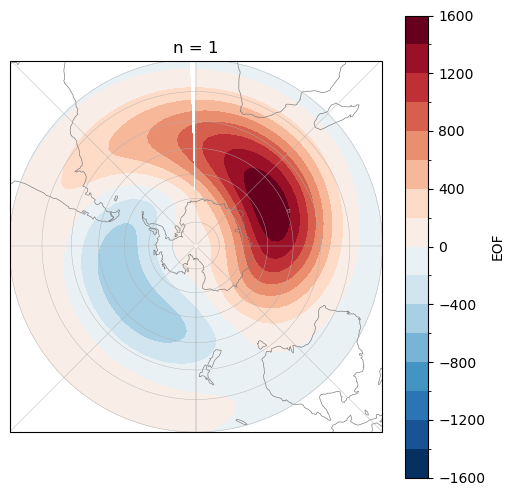

In [17]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof_physical.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

- extract eigenvector

In [36]:
# 1. Select Mode 1 (index 0 in Python)
# u usually has shape (lat, lon, modes) based on your function
u_mode1 = -1*u[:, :, 0]

# 2. Wrap it in an xarray.DataArray
# 'da_wgt' or 'z_mon' is your original data object used to get lat/lon
u_da = xr.DataArray(
    u_mode1, 
    coords={'lat': da_wgt.lat, 'lon': da_wgt.lon}, 
    dims=('lat', 'lon'),
    name='Eigenvector 1'
)

2. Project monthly eof/ eigenvector to daily anomalies

In [21]:
# for mon in mons:

gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

gh_day_mon = gh_6h_mon['var129'].resample(time="1D").mean()

# Convert to meters
z_m = gh_day_mon / 9.8

# Compute climatology in meters
z_clim = z_m.groupby("time.dayofyear").mean("time")

# Compute anomalies (unweighted)
z_anom = z_m.groupby("time.dayofyear") - z_clim


/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 45 times more chunks
  return self.array[key]


In [23]:
# THEN apply weights
w = np.sqrt(np.cos(np.deg2rad(z_anom['lat'])))

z_anom_wgt = z_anom*np.sqrt(w)

print('select weighted daily anomalies for mon = %s' % mon)
anom_mon = z_anom_wgt.where(z_anom_wgt['time'].dt.month==mon, drop=True)

select anomalies for mon = 6


In [37]:
# project eigenvector to daily anomalies
pc_raw = anom_mon.dot(u_da, dims=('lat', 'lon'))

In [43]:
pc_raw = (anom_mon * u_da).sum(dim=('lat', 'lon'))

In [44]:
# 6. Standardization (FIX: Match NCL's dim_standardize_n_Wrap(ts,1,0))
# NCL standardizes each calendar day (0..365) separately across years.
# We use groupby('day') to normalize June 1sts relative to other June 1sts.
def standardize(x):
    return (x - x.mean()) / x.std(ddof=0)

pc_std = pc_raw.groupby("time.dayofyear").map(standardize)

In [45]:
pc_std[:30].values

array([-0.20721097, -0.20064363, -0.26313066, -0.31068463, -0.13673016,
        0.1295681 ,  0.14213689, -0.0913404 , -0.29166673, -0.25901831,
       -0.21718532, -0.33563994, -0.35807015, -0.292951  , -0.21088767,
       -0.09883677, -0.05800049, -0.1775299 , -0.10066444,  0.11430721,
        0.30520354,  0.2805007 ,  0.0152235 , -0.23479491, -0.30136257,
       -0.16030842, -0.05403482,  0.29716643,  0.7257274 ,  1.14230801])

- from eunpa's: 
- the pcs for 197906 are:

1.013    0.963    0.955    0.893    0.680    0.468    0.561    0.874    1.104    1.021    0.932    0.961    0.906    0.802    0.613    0.306    0.089    0.070   -0.001   -0.105   -0.177    0.004    0.306    0.472    0.435    0.249   -0.229   -0.498   -0.814   -1.168
